# WFS y GeoJSON API con GeoPandas

En este notebook aprenderas a consumir datos geoespaciales desde servicios web y a cargarlos en Python con `geopandas`, usando como caso real los centros educativos de Aragon.

## Objetivos

- Entender la diferencia entre un servicio **WFS** y una **GeoJSON API**.
- Cargar capas geoespaciales remotas en un `GeoDataFrame`.
- Explorar, visualizar y filtrar datos espaciales con un caso educativo real.
- Exportar una seleccion a GeoJSON para reutilizarla.

## 1) Conceptos clave

### WFS (Web Feature Service)
- Estandar OGC para consultar **entidades vectoriales** (puntos, lineas, poligonos).
- Normalmente permite filtrar por atributos, extension espacial y formato de salida.
- Muy comun en infraestructuras de datos espaciales institucionales.

### GeoJSON API
- API web que entrega directamente objetos en formato **GeoJSON**.
- Suele ser mas simple de consumir desde Python y front-end web.
- No siempre sigue el estandar OGC, pero es muy practica.

> En la practica, ambos te permiten traer geometria + atributos a un `GeoDataFrame`.

In [ ]:
# Si falta alguna dependencia, descomenta esta celda
# %pip install geopandas requests matplotlib pyogrio

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

## 2) Ejemplo A: Cargar datos desde una GeoJSON API

Usaremos un endpoint de Open Data Aragon con informacion de centros educativos.

> Nota: el servicio puede devolver distintos tipos de centros. En el analisis filtraremos especificamente colegios publicos.

In [ ]:
geojson_url = "https://opendata.aragon.es/GA_OD_Core/download?view_id=167&formato=json"

gdf_geojson = gpd.read_file(geojson_url)

# El servicio declara EPSG:4326, pero las coordenadas vienen en UTM zona 30N.
# Reasignamos el CRS correcto antes de reproyectar o combinar con otras capas.
gdf_geojson = gdf_geojson.set_crs(epsg=25830, allow_override=True)

gdf_geojson.head()

In [ ]:
print("CRS:", gdf_geojson.crs)
print("Numero de entidades:", len(gdf_geojson))
print("Columnas principales:", ["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"])

# Vista rapida de campos clave
gdf_geojson[["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"]].head()

In [ ]:
ax = gdf_geojson.plot(edgecolor="black", alpha=0.6, markersize=20)
ax.set_title("Centros educativos en Aragon (GeoJSON API)")
ax.set_axis_off()

In [14]:
gdf_geojson["naturaleza"]=="Público"

0       True
1       True
2       True
3      False
4       True
       ...  
891    False
892    False
893     True
894     True
895     True
Name: naturaleza, Length: 896, dtype: bool

## 3) Limpieza y filtrado: colegios publicos de Aragon

El dataset incluye diferentes tipos de centros. Vamos a quedarnos con los centros cuya `naturaleza` sea publica y cuyo tipo contenga "Colegio Publico".

Esto permite construir un ejemplo mas realista de seleccion por atributos.

In [ ]:
gdf_colegios_publicos = gdf_geojson[
    (gdf_geojson["naturaleza"].str.contains("Público", case=False, na=False))
].copy()
# equiv.  gdf_geojson[gdf_geojson["naturaleza"]=="Público"].copy()

gdf_colegios_publicos[["nombre_cen", "tipo_centr", "naturaleza", "localidad", "geometry"]].head()

In [ ]:
print("CRS:", gdf_colegios_publicos.crs)
print("Numero de colegios publicos:", len(gdf_colegios_publicos))
print("Numero de localidades representadas:", gdf_colegios_publicos["localidad"].nunique())

In [ ]:
ax = gdf_colegios_publicos.plot(color="royalblue", edgecolor="black", markersize=18)
ax.set_title("Colegios publicos en Aragon")
ax.set_axis_off()

## 4) Analisis rapido por localidad

Una pregunta docente frecuente es: "que localidades tienen mas colegios publicos?".

Podemos resolverlo con un conteo por `localidad`.

In [17]:
top_localidades = (
    gdf_colegios_publicos.groupby("localidad")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="num_colegios")
)

top_localidades.head(10)

,localidad,num_colegios
0,Zaragoza,143
1,Huesca,21
2,Teruel,17
3,Calatayud,11
4,Alcañiz,10
5,Fraga,10
6,Utebo,10
7,Jaca,10
8,Ejea De Los Caballeros,9
9,Barbastro,8


Text(0, 0.5, 'Numero de colegios')

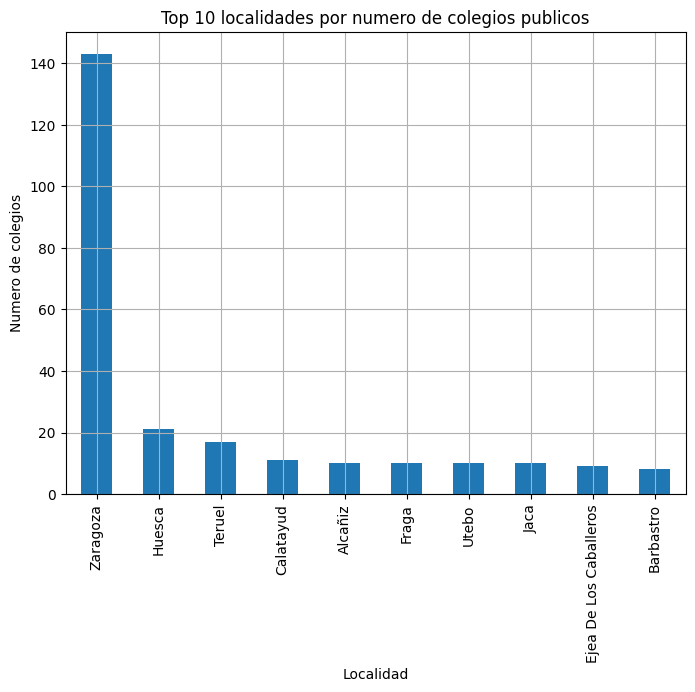

In [18]:
ax = top_localidades.head(10).plot.bar(x="localidad", y="num_colegios", legend=False)
ax.set_title("Top 10 localidades por numero de colegios publicos")
ax.set_xlabel("Localidad")
ax.set_ylabel("Numero de colegios")

## 5) Exportar resultado a GeoJSON

Guardar la seleccion de colegios publicos es util para compartir resultados o usarlos en visores web.

In [ ]:
salida_geojson = "data/colegios_publicos_aragon.geojson"
gdf_colegios_publicos.to_file(salida_geojson, driver="GeoJSON")
print(f"Archivo exportado: {salida_geojson}")

## 6) Ejemplo B: Cargar datos desde WFS (IDEE Transportes)

Ahora usamos un servicio WFS real de IDEE/IGN:

- Servicio: `https://servicios.idee.es/wfs-inspire/transportes`
- Operacion: `request=GetFeature`
- Capa de ejemplo: `tn-ro:RoadLink`

Este servicio suele devolver GML, y `geopandas` lo puede leer directamente.


In [ ]:
# Ejemplo WFS fijo con la capa solicitada: tn-ro:RoadLink
# Para que el ejemplo sea rapido y legible, usamos una zona urbana concreta.
# Estas coordenadas estan en EPSG:25830, el CRS de los colegios.
colegios_zaragoza = gdf_colegios_publicos[
    gdf_colegios_publicos["localidad"].str.contains("Zaragoza", case=False, na=False)
].cx[670000:681000, 4609000:4620000].copy()

# Construimos un bbox a partir de esos colegios, con un pequeno margen en grados.
xmin, ymin, xmax, ymax = colegios_zaragoza.to_crs(4326).total_bounds
margen = 0.01
bbox_escuelas = f"{xmin-margen},{ymin-margen},{xmax+margen},{ymax+margen},EPSG:4326"

url_wfs_aragon = (
    "https://servicios.idee.es/wfs-inspire/transportes?"
    "service=WFS&version=2.0.0&request=GetFeature&"
    "typeNames=tn-ro:RoadLink&count=3000&"
    f"srsName=EPSG:4326&bbox={bbox_escuelas}"
)

gdf_wfs_aragon = gpd.read_file(url_wfs_aragon)
print("Colegios publicos en Zaragoza:", len(colegios_zaragoza))
print("Entidades WFS cargadas:", len(gdf_wfs_aragon))
print("BBox usado:", bbox_escuelas)
gdf_wfs_aragon.head()

In [ ]:
len(gdf_wfs_aragon) #! Look the number of entities. Are they all in Aragon?

In [ ]:
# Plot the data
ax = gdf_wfs_aragon.plot(color="darkgreen", linewidth=4)
ax.set_title("WFS IDEE Transportes - tn-ro:RoadLink")
ax.set_axis_off()
#! Look at the data


## 8) Ejemplo C: Operaciones sobre datos vectoriales

En este bloque combinamos capas, aplicamos operaciones espaciales y calculamos metricas basicas para analisis territorial.

In [ ]:
# C.2 Combinar dos GeoDataFrames: colegios publicos + red de carreteras
# Usamos un CRS metrico para que las distancias y longitudes esten en metros.
crs_metrico = 25830

colegios_m = colegios_zaragoza.to_crs(epsg=crs_metrico)
red_m = gdf_wfs_aragon.to_crs(epsg=crs_metrico)

# Limpiamos geometrias nulas o vacias antes de operar.
colegios_m = colegios_m[colegios_m.geometry.notna() & ~colegios_m.geometry.is_empty].copy()
red_m = red_m[red_m.geometry.notna() & ~red_m.geometry.is_empty].copy()

# Recortamos la red al area ocupada por los colegios, con un margen de 1 km.
xmin, ymin, xmax, ymax = colegios_m.total_bounds
margen_m = 1000
red_recortada = red_m.cx[xmin-margen_m:xmax+margen_m, ymin-margen_m:ymax+margen_m].copy()
red_recortada["longitud_m"] = red_recortada.geometry.length

print("Colegios publicos en el area:", len(colegios_m))
print("Tramos de carretera en el area:", len(red_recortada))
print("Longitud total de red (km):", round(red_recortada["longitud_m"].sum() / 1000, 2))

fig, ax = plt.subplots(figsize=(10, 8))

if red_recortada.empty:
    colegios_m.plot(ax=ax, color="crimson", markersize=18, alpha=0.9, label="Colegios publicos")
    ax.set_title("Colegios publicos de Zaragoza")
else:
    red_recortada.plot(ax=ax, color="steelblue", linewidth=1, alpha=0.75, label="Red de carreteras")
    colegios_m.plot(ax=ax, color="crimson", edgecolor="white", markersize=24, alpha=0.9, label="Colegios publicos")
    ax.set_title("Colegios publicos y red de carreteras en Zaragoza")

ax.legend()
ax.set_axis_off()

## 9) Actividades propuestas

1. Filtra solo centros de una provincia concreta.
2. Reproyecta los datos a EPSG:3857 y vuelve a graficar.
3. En el WFS, prueba otro `typeNames` del `GetCapabilities`.
4. Compara esquema de columnas y geometria entre GeoJSON y WFS.

## Cierre

Con `geopandas` puedes integrar datos remotos (GeoJSON API o WFS) en flujos de analisis espacial de forma directa y reproducible.